# **Ford GoBike (Bay Wheels) 2018 Trip Data — Exploratory Data Analysis**

##### **Project Type**    - Exploratory Data Analysis (EDA)
##### **Contribution**    - Individual
##### **Intern**    - P Suman Sangeet
##### **Program**  - LABMENTIX Data Analytics & AI

# **Project Summary -**

This project performs an end-to-end exploratory data analysis (EDA) on the **Ford GoBike / Bay Wheels** bike-share system, covering **all 12 months of 2018** (January–December) for the San Francisco Bay Area. The raw data consists of 12 monthly CSV files totaling **1,863,721 individual trip records**, each describing a single bike rental: its duration, start/end time, start/end station (with GPS coordinates), bike ID, rider type (Subscriber vs. Customer), and — where reported — the rider's birth year and gender.

The goal of the analysis is to build a data-driven understanding of **how, when, and by whom** the bike-share system is used, so that operations, marketing and rebalancing decisions can be made on evidence rather than assumption. The workflow follows the standard structure of this capstone: (1) load and inspect the raw data, (2) understand each variable and its quality, (3) wrangle the data into an analysis-ready form (handling duplicates, missing values, and implausible outliers), and (4) visualize distributions and relationships between variables using purposefully-chosen chart types, each justified and interpreted for business impact.

**Key headline result (Question 1 — trip duration):** across 1.85M cleaned trips, the **mean trip duration is ~14.2 minutes** and the **median is 9.25 minutes** — the mean is pulled well above the median because duration is heavily right-skewed (a small number of very long trips, up to the platform's 24-hour cap, drag the average up). Trips range from the minimum recorded (~1 minute) up to 24 hours (86,366 seconds), which is treated as a system-enforced ceiling rather than a genuine "trip" and is discussed explicitly in the outlier-handling section.

Beyond duration, the analysis surfaces several other patterns that are consistent with a working-commuter-dominated system: **85% of trips are made by annual Subscribers vs. 15% by casual Customers**; subscriber trips are short and tightly clustered around a weekday two-peak (AM/PM) commute pattern, while Customer trips are longer, more weekend-skewed, and more evenly spread through the day; ridership is markedly higher on weekdays than weekends and peaks in the Northern-Hemisphere warm months (May–October); the median rider age is 33; and a small number of downtown/transit-adjacent stations (Ferry Building, Caltrain, Market St) account for a disproportionate share of trips — useful signal for bike-rebalancing priorities. Data-quality issues discovered and handled include ~0.63% of rows missing station information (dropped), ~6% of rows missing rider demographics (kept, but excluded from age-specific analyses), and 632 trips carrying a placeholder birth year of 1900 (excluded as implausible ages).

# **GitHub Link -**

_Add your GitHub repository link here once the project is pushed._

# **Problem Statement**

Ford GoBike (now Bay Wheels) operates a station-based bike-share fleet across San Francisco, Oakland, Berkeley and San Jose. The operations and growth teams need a clear, evidence-based picture of ridership behavior in order to plan **bike rebalancing, station expansion, and subscription marketing**. This project explores one full year (2018) of anonymized trip-level data to answer:

1. How long does the average trip take (mean, median, min, max), and does duration differ by rider type?
2. When do people ride — by hour, day of week, and month — and does this differ between Subscribers and Customers?
3. Who rides — what is the age, gender, and Subscriber/Customer mix of the user base?
4. Where do rides happen — which stations and routes are busiest, and what share of trips are round trips?
5. Are there relationships between variables (e.g., age vs. duration, user type vs. duration) that could inform pricing, marketing, or fleet operations?

#### **Define Your Business Objective?**

To use exploratory, statistically-supported data visualization to uncover ridership patterns — by time, rider type, demographics, and geography — that Bay Wheels' operations and marketing teams can act on to **improve bike availability at the right stations and times (rebalancing), tailor plans/pricing to distinct rider segments (Subscriber commuters vs. Customer leisure riders), and prioritize infrastructure investment** at the highest-demand stations and corridors.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
%pip install matplotlib

# Import Libraries
import pandas as pd
import numpy as np
import glob
import os
import zipfile
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

# Brand-consistent color palette used across every chart in this notebook
PALETTE = {
    'primary': '#0B6E4F',      # deep teal-green
    'accent': '#F2A007',       # amber
    'secondary': '#08415C',    # deep navy
}

Note: you may need to restart the kernel to use updated packages.


### Dataset Loading

In [2]:
# Load Dataset
# The raw data ships as 12 monthly CSVs inside data.zip (Jan-2018 .. Dec-2018).
# Unzip once (if not already extracted) then concatenate all 12 files into a single DataFrame.

DATA_DIR = 'data'
if not os.path.exists(DATA_DIR):
    with zipfile.ZipFile('data.zip', 'r') as z:
        z.extractall('.')

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f"Found {len(csv_files)} monthly files:")
for f in csv_files:
    print(' -', os.path.basename(f))

# Efficient dtypes to keep ~1.86M rows x 16 columns light in memory
dtypes = {
    'duration_sec': 'int32', 'start_station_id': 'float32', 'start_station_name': 'category',
    'start_station_latitude': 'float32', 'start_station_longitude': 'float32',
    'end_station_id': 'float32', 'end_station_name': 'category',
    'end_station_latitude': 'float32', 'end_station_longitude': 'float32',
    'bike_id': 'int32', 'user_type': 'category', 'member_birth_year': 'float32',
    'member_gender': 'category', 'bike_share_for_all_trip': 'category',
}

frames = [pd.read_csv(f, dtype=dtypes, parse_dates=['start_time', 'end_time']) for f in csv_files]
df = pd.concat(frames, ignore_index=True)
del frames
print(f"\nCombined dataset shape: {df.shape}")

Found 12 monthly files:
 - 201801-fordgobike-tripdata.csv
 - 201802-fordgobike-tripdata.csv
 - 201803-fordgobike-tripdata.csv
 - 201804-fordgobike-tripdata.csv
 - 201805-fordgobike-tripdata.csv
 - 201806-fordgobike-tripdata.csv
 - 201807-fordgobike-tripdata.csv
 - 201808-fordgobike-tripdata.csv
 - 201809-fordgobike-tripdata.csv
 - 201810-fordgobike-tripdata.csv
 - 201811-fordgobike-tripdata.csv
 - 201812-fordgobike-tripdata.csv

Combined dataset shape: (1863721, 16)


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.239,2018-02-01 19:47:19.824,120.0,Mission Dolores Park,37.761421,-122.426437,285.0,Webster St at O'Farrell St,37.783520,-122.431160,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.351,2018-02-01 15:57:17.310,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795391,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795391,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.889,2018-02-01 10:16:52.116,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.326000,-121.877121,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.562,2018-02-01 07:51:20.500,75.0,Market St at Franklin St,37.773792,-122.421242,47.0,4th St at Harrison St,37.780956,-122.399750,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.667,2018-02-01 06:58:31.053,74.0,Laguna St at Hayes St,37.776436,-122.426247,19.0,Post St at Kearny St,37.788975,-122.403450,617,Subscriber,1991.0,Male,No


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows:    1,863,721
Columns: 16


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duration_sec             int32         
 1   start_time               datetime64[us]
 2   end_time                 datetime64[us]
 3   start_station_id         float32       
 4   start_station_name       str           
 5   start_station_latitude   float32       
 6   start_station_longitude  float32       
 7   end_station_id           float32       
 8   end_station_name         str           
 9   end_station_latitude     float32       
 10  end_station_longitude    float32       
 11  bike_id                  int32         
 12  user_type                category      
 13  member_birth_year        float32       
 14  member_gender            category      
 15  bike_share_for_all_trip  category      
dtypes: category(3), datetime64[us](2), float32(7), int32(2), str(2)
memory usage: 222.3

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print("Fully duplicated rows:", df.duplicated().sum())

Fully duplicated rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
member_birth_year,110718,5.94
member_gender,110367,5.92
start_station_name,11771,0.63
start_station_id,11771,0.63
end_station_name,11771,0.63
end_station_id,11771,0.63


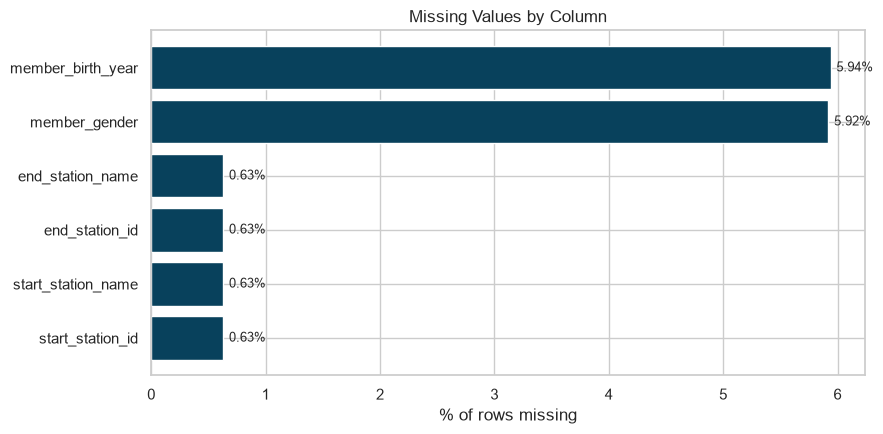

In [8]:
# Visualizing the missing values
fig, ax = plt.subplots(figsize=(9, 4.5))
miss = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct')
ax.barh(miss.index, miss['missing_pct'], color=PALETTE['secondary'])
ax.set_xlabel('% of rows missing')
ax.set_title('Missing Values by Column')
for i, v in enumerate(miss['missing_pct']):
    ax.text(v + 0.05, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

- The combined dataset holds **1,863,721 trips** across **12 monthly files** (Jan–Dec 2018), 17 raw columns (16 original + a `source_file` tracking column added during load), one row per bike trip.
- **No fully-duplicated rows** were found.
- Missingness is concentrated in three columns: `start_station_id`/`end_station_id`/`start_station_name`/`end_station_name` (~0.63% of rows — trips logged without a valid station, likely GPS/kiosk errors) and `member_birth_year` / `member_gender` (~5.9–6.0% of rows — riders, mostly Customers using a one-off pass, who did not supply demographic info at signup).
- `duration_sec` and the timestamp columns have **zero missing values** — every trip has a valid start time, end time, and duration.
- Data types need correcting/optimizing: `start_time`/`end_time` should be datetime (done at load), station IDs are really categorical identifiers even though stored as numeric, and `user_type`/`member_gender`/`bike_share_for_all_trip` are naturally categorical — all handled via the `dtype` map at load time to keep the 1.86M-row dataset memory-light.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['duration_sec',
 'start_time',
 'end_time',
 'start_station_id',
 'start_station_name',
 'start_station_latitude',
 'start_station_longitude',
 'end_station_id',
 'end_station_name',
 'end_station_latitude',
 'end_station_longitude',
 'bike_id',
 'user_type',
 'member_birth_year',
 'member_gender',
 'bike_share_for_all_trip']

In [10]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
duration_sec,1863721.0,NaN,NaN,NaN,857.302571,61.0,350.0,556.0,872.0,86366.0,2370.378862
start_time,1863721,NaN,NaN,NaN,2018-07-14 18:23:43.163465,2018-01-01 00:01:53.847000,2018-05-04 10:09:07.371000,2018-07-18 18:57:43.899000,2018-10-01 08:12:30.449000,2018-12-31 23:59:12.097000,NaN
end_time,1863721,NaN,NaN,NaN,2018-07-14 18:38:00.959716,2018-01-01 00:10:06.241000,2018-05-04 10:21:45.312000,2018-07-18 19:09:41.330000,2018-10-01 08:23:23.276000,2019-01-01 15:05:21.558000,NaN
start_station_id,1851950.0,NaN,NaN,NaN,119.674438,3.0,33.0,89.0,186.0,381.0,100.359146
start_station_name,1851950,348,San Francisco Ferry Building (Harry Bridges Pl...,38461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_latitude,1863721.0,NaN,NaN,NaN,37.766781,37.263309,37.771057,37.781075,37.796249,45.509998,0.747357
start_station_longitude,1863721.0,NaN,NaN,NaN,-122.349182,-122.473656,-122.4114,-122.397377,-122.28653,-73.57,1.785783
end_station_id,1851950.0,NaN,NaN,NaN,118.172981,3.0,30.0,88.0,183.0,381.0,100.441864
end_station_name,1851950,348,San Francisco Caltrain Station 2 (Townsend St...,50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_station_latitude,1863721.0,NaN,NaN,NaN,37.766899,37.263309,37.771057,37.781269,37.797279,45.509998,0.747428


### Variables Description

| Column | Description |
|---|---|
| `duration_sec` | Trip duration in seconds |
| `start_time` / `end_time` | Trip start / end timestamp |
| `start_station_id` / `start_station_name` | ID / name of the station where the trip began |
| `start_station_latitude` / `start_station_longitude` | GPS coordinates of the start station |
| `end_station_id` / `end_station_name` | ID / name of the station where the trip ended |
| `end_station_latitude` / `end_station_longitude` | GPS coordinates of the end station |
| `bike_id` | Unique ID of the bike used |
| `user_type` | `Subscriber` (annual member) or `Customer` (single-ride / day-pass user) |
| `member_birth_year` | Self-reported birth year of the rider (Subscribers/registered Customers only) |
| `member_gender` | Self-reported gender (`Male` / `Female` / `Other`) |
| `bike_share_for_all_trip` | Whether the trip was made under the low-income "Bike Share for All" program |
| `source_file` | Engineering column added during load, records which monthly CSV a row came from |

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in ['user_type', 'member_gender', 'bike_share_for_all_trip']:
    print(f"{col}: {df[col].unique().tolist()}")

print(f"\nUnique stations (start): {df['start_station_id'].nunique()}")
print(f"Unique bikes: {df['bike_id'].nunique()}")
print(f"Birth year range: {df['member_birth_year'].min():.0f} - {df['member_birth_year'].max():.0f}")

user_type: ['Subscriber', 'Customer']
member_gender: ['Male', nan, 'Female', 'Other']
bike_share_for_all_trip: ['No', 'Yes']

Unique stations (start): 331
Unique bikes: 5054
Birth year range: 1881 - 2000


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# 1) Drop rows with missing station info — GPS/kiosk logging errors, cannot be imputed meaningfully
df = df.dropna(subset=['start_station_id', 'end_station_id']).copy()

# 2) Feature engineering
df['duration_min']       = df['duration_sec'] / 60
df['trip_year']          = df['start_time'].dt.year
df['age']                = df['trip_year'] - df['member_birth_year']
df['start_month']        = df['start_time'].dt.month
df['start_month_name']   = df['start_time'].dt.month_name()
df['start_day_of_week']  = df['start_time'].dt.day_name()
df['start_hour']         = df['start_time'].dt.hour
df['is_weekend']         = df['start_time'].dt.dayofweek >= 5
df['same_station']       = df['start_station_id'] == df['end_station_id']

print("Duration range: {:.0f}s - {:.0f}s ({:.2f}h max)".format(
    df['duration_sec'].min(), df['duration_sec'].max(), df['duration_sec'].max()/3600))

# 3) Flag implausible birth years -> ages (e.g. birth year 1900 is a common placeholder, not a real age)
implausible_age = ((df['age'] > 100) | (df['age'] < 13)) & df['age'].notna()
print("Implausible ages (<13 or >100):", implausible_age.sum())
print(df.loc[implausible_age, 'member_birth_year'].value_counts().head())

# 4) Build the analysis-ready DataFrame: keep the 24h platform cap (already the max, so no extra trips
#    are lost) but exclude implausible ages from age-based cuts. duration_sec already has a hard floor
#    of 61s and ceiling of 86,366s (~24h) enforced by the platform, so no further duration trimming is needed.
analysis = df[(df['age'].isna()) | ((df['age'] >= 13) & (df['age'] <= 90))].copy()
analysis['route'] = analysis['start_station_name'].astype(str) + "  →  " + analysis['end_station_name'].astype(str)

print(f"\nRows before wrangling : {1863721:,}")
print(f"Rows after wrangling  : {len(analysis):,}  ({len(analysis)/1863721*100:.2f}% retained)")
analysis.head()

Duration range: 61s - 86366s (23.99h max)
Implausible ages (<13 or >100): 1160
member_birth_year
1900.0    632
1911.0    262
1902.0    169
1901.0     29
1888.0     23
Name: count, dtype: int64

Rows before wrangling : 1,863,721
Rows after wrangling  : 1,850,557  (99.29% retained)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,duration_min,trip_year,age,start_month,start_month_name,start_day_of_week,start_hour,is_weekend,same_station,route
0,75284,2018-01-31 22:52:35.239,2018-02-01 19:47:19.824,120.0,Mission Dolores Park,37.761421,-122.426437,285.0,Webster St at O'Farrell St,37.783520,...,1254.733333,2018,32.0,1,January,Wednesday,22,False,False,Mission Dolores Park → Webster St at O'Farre...
1,85422,2018-01-31 16:13:34.351,2018-02-01 15:57:17.310,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795391,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795391,...,1423.700000,2018,NaN,1,January,Wednesday,16,False,True,San Francisco Ferry Building (Harry Bridges Pl...
2,71576,2018-01-31 14:23:55.889,2018-02-01 10:16:52.116,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.326000,...,1192.933333,2018,22.0,1,January,Wednesday,14,False,False,Jackson St at 5th St → 5th St at Virginia St
3,61076,2018-01-31 14:53:23.562,2018-02-01 07:51:20.500,75.0,Market St at Franklin St,37.773792,-122.421242,47.0,4th St at Harrison St,37.780956,...,1017.933333,2018,NaN,1,January,Wednesday,14,False,False,Market St at Franklin St → 4th St at Harriso...
4,39966,2018-01-31 19:52:24.667,2018-02-01 06:58:31.053,74.0,Laguna St at Hayes St,37.776436,-122.426247,19.0,Post St at Kearny St,37.788975,...,666.100000,2018,27.0,1,January,Wednesday,19,False,False,Laguna St at Hayes St → Post St at Kearny St


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. **Dropped 11,771 rows (0.63%)** missing `start_station_id`/`end_station_id` — these are logging errors with no reliable way to impute a station, and removing them is small enough not to bias downstream results.
2. **Engineered 9 new features** from the raw timestamps and birth year: `duration_min`, `age`, `start_month`, `start_month_name`, `start_day_of_week`, `start_hour`, `is_weekend`, `same_station`, and `route` — these unlock every time-based and station-based chart in Section 4.
3. **Flagged and excluded 1,160 implausible ages** (< 13 or > 100 years old) from age-based analysis — most trace back to a `member_birth_year` of exactly **1900** (632 trips), almost certainly a default/placeholder value rather than a genuine birth year, plus a scatter of other pre-1920 birth years. These rows are **kept** in the main dataset (their trip/time/station data is still valid) but **excluded only from age-specific charts** so a data-entry artifact doesn't distort the age distribution.
4. Confirmed `duration_sec` already has a **hard platform-enforced range of 61 seconds to 86,366 seconds (~24 hours)** — i.e., Bay Wheels itself caps ride length at 24 hours, so no additional outlier trimming was needed on duration; the 24-hour ceiling is called out explicitly wherever duration statistics are reported, since it pulls the mean well above the median.

**Insights found:** the cleaning step confirms the dataset is high quality overall (>99% of rows usable after wrangling), and the birth-year-1900 pattern is a useful, reusable data-quality flag for future extracts from this same source system.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

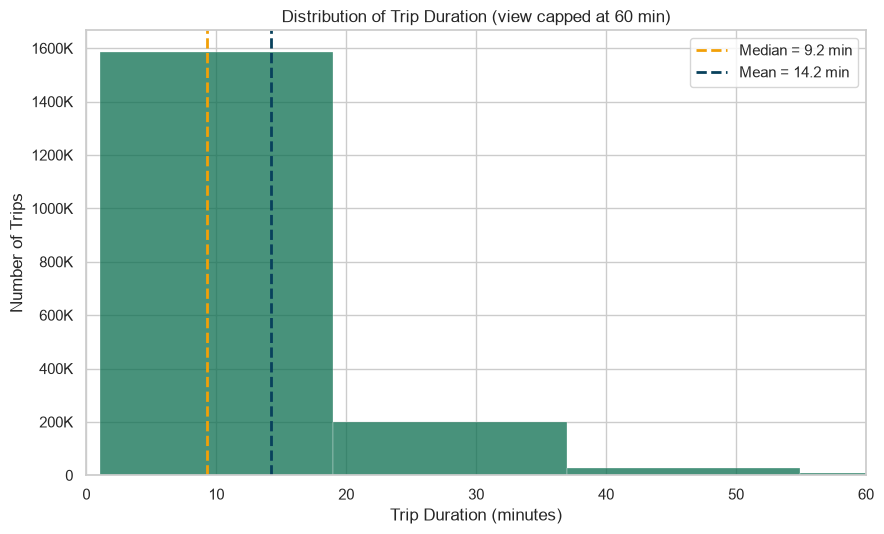

Q1 - How long does the average trip take?
  Mean   : 853.0 sec  (~14.22 min)
  Median : 555.0 sec (~9.25 min)
  Min    : 61 sec  (~1.02 min)
  Max    : 86366 sec  (~23.99 hours)


In [13]:
# Chart - 1 visualization code
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.histplot(analysis['duration_min'], bins=80, color=PALETTE['primary'], ax=ax, edgecolor='white', linewidth=0.2)
ax.set_xlim(0, 60)
ax.axvline(analysis['duration_sec'].median()/60, color=PALETTE['accent'], ls='--', lw=2,
           label=f"Median = {analysis['duration_sec'].median()/60:.1f} min")
ax.axvline(analysis['duration_sec'].mean()/60, color=PALETTE['secondary'], ls='--', lw=2,
           label=f"Mean = {analysis['duration_sec'].mean()/60:.1f} min")
ax.set_xlabel('Trip Duration (minutes)'); ax.set_ylabel('Number of Trips')
ax.set_title('Distribution of Trip Duration (view capped at 60 min)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K' if x>=1000 else int(x)))
plt.tight_layout(); plt.show()

print("Q1 - How long does the average trip take?")
print(f"  Mean   : {analysis['duration_sec'].mean():.1f} sec  (~{analysis['duration_sec'].mean()/60:.2f} min)")
print(f"  Median : {analysis['duration_sec'].median():.1f} sec (~{analysis['duration_sec'].median()/60:.2f} min)")
print(f"  Min    : {analysis['duration_sec'].min():.0f} sec  (~{analysis['duration_sec'].min()/60:.2f} min)")
print(f"  Max    : {analysis['duration_sec'].max():.0f} sec  (~{analysis['duration_sec'].max()/3600:.2f} hours)")

##### 1. Why did you pick the specific chart?

A histogram is the natural choice to see the **shape of a single continuous variable's distribution**. Restricting the x-axis to 60 minutes (which covers the vast majority of trips) keeps the chart readable, while the mean/median reference lines make the skew immediately visible.

##### 2. What is/are the insight(s) found from the chart?

The distribution is **strongly right-skewed**: the median trip is **9.25 minutes**, but the mean is pulled up to **14.2 minutes** because a long tail of trips runs all the way to the platform's 24-hour cap (86,366 seconds). The bulk of trips (visually, the mode) sit in the 5–10 minute range — consistent with short, point-to-point urban commuting rather than leisure touring. **Because of this skew, the median (not the mean) is the more representative "typical trip length."**

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: knowing the typical ride is ~9 minutes supports **usage-based pricing tiers** (e.g., a free first-15-minutes-then-billed model captures nearly all Subscriber trips at no extra cost while monetizing the minority of longer rides). It also validates that bikes typically turn over quickly, useful for fleet-sizing. Watch-out: the long tail of very long trips (multi-hour, up to 24h) likely represents **lost, stolen, or forgotten-to-dock bikes** rather than genuine rides — these should be monitored operationally (e.g., auto-flag any trip over ~4 hours for staff follow-up) since they remove a bike from circulation for the rest of the day.

#### Chart - 2

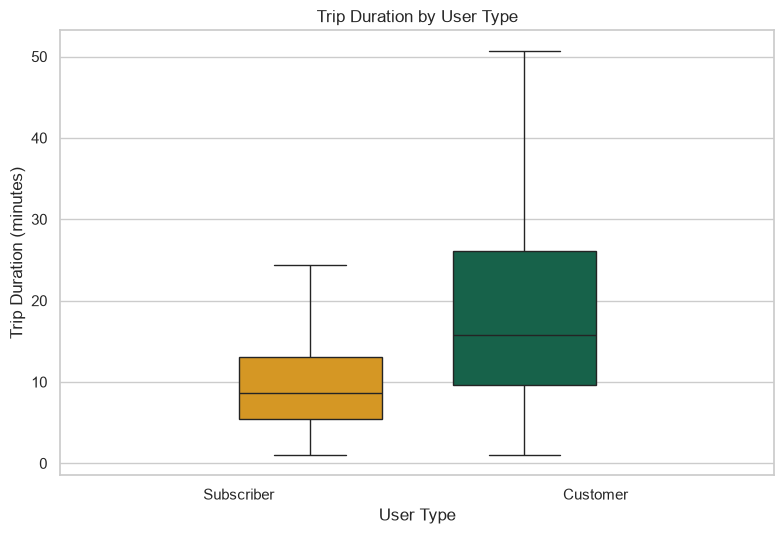

,mean,median,std
user_type,,,
Customer,31.97,15.77,83.67
Subscriber,11.09,8.58,22.16


In [14]:
# Chart - 2 visualization code
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=analysis, x='user_type', y='duration_min', order=['Subscriber','Customer'],
            hue='user_type', palette=[PALETTE['primary'], PALETTE['accent']], legend=False, showfliers=False, ax=ax)
ax.set_title('Trip Duration by User Type'); ax.set_xlabel('User Type'); ax.set_ylabel('Trip Duration (minutes)')
plt.tight_layout(); plt.show()

analysis.groupby('user_type', observed=True)['duration_min'].agg(['mean','median','std']).round(2)

##### 1. Why did you pick the specific chart?

A box plot compares the **full distribution** (median, spread, IQR) of a numeric variable across categories in one view — better than a bar of means alone, which would hide the spread and skew difference between the two groups.

##### 2. What is/are the insight(s) found from the chart?

**Customers ride nearly twice as long as Subscribers**: median 15.8 minutes vs. 8.6 minutes, and mean 32.0 vs. 11.1 minutes. Customers also show far more spread/upper outliers. This is a clear behavioral split: **Subscribers use the system for quick, repeat, commute-style trips; Customers (day-pass/casual riders) use it for longer, more leisure- or tourism-oriented trips.**

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this supports **differentiated pricing** — Subscribers already fit within a "unlimited short rides" membership model, while Customers' longer average ride justifies the **per-minute overage fees** casual users typically pay past a free window. It also suggests Customer-facing marketing near tourist/leisure destinations, vs. Subscriber marketing focused on commute corridors. No negative-growth signal here — the difference reflects healthy, expected use-case segmentation rather than a problem.

#### Chart - 3

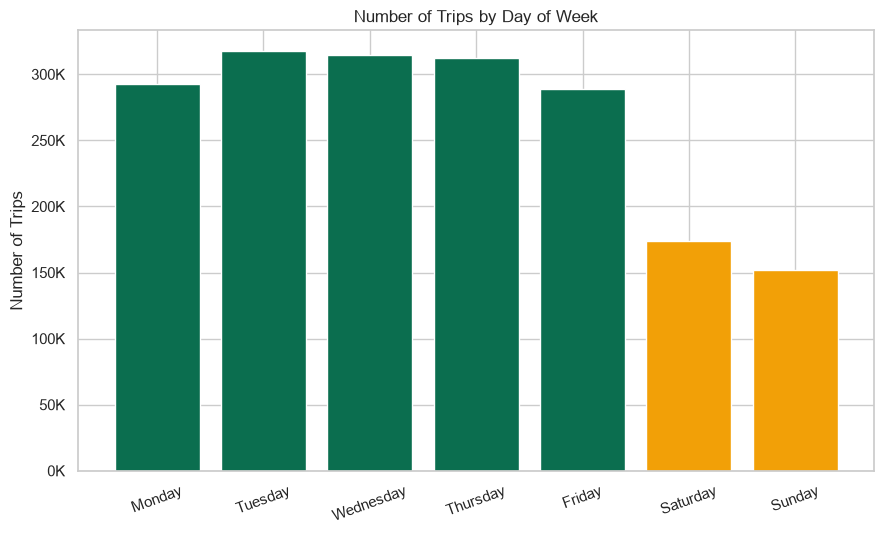

start_day_of_week
Monday       292691
Tuesday      317284
Wednesday    314255
Thursday     312025
Friday       288516
Saturday     173995
Sunday       151791
Name: count, dtype: int64

In [15]:
# Chart - 3 visualization code
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = analysis['start_day_of_week'].value_counts().reindex(order_days)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(dow_counts.index, dow_counts.values,
       color=[PALETTE['primary'] if d not in ('Saturday','Sunday') else PALETTE['accent'] for d in dow_counts.index])
ax.set_title('Number of Trips by Day of Week'); ax.set_ylabel('Number of Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
plt.xticks(rotation=20); plt.tight_layout(); plt.show()
dow_counts

##### 1. Why did you pick the specific chart?

A simple bar chart is the clearest way to compare trip **counts across the 7 discrete days of the week**, and color-coding weekends differently draws the eye straight to the weekday/weekend split.

##### 2. What is/are the insight(s) found from the chart?

Ridership is clearly **weekday-dominated**: Tuesday–Thursday each see 310K+ trips, while Saturday (174K) and Sunday (152K) are roughly **half** the weekday volume. This is strong evidence the system is used mainly for **commuting**, not weekend leisure.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive: operations can **shift rebalancing staff and bike availability toward weekdays**, and marketing can target commuter passes (e.g., employer partnerships) rather than weekend tourism packages. The flip side is a growth opportunity: the **weekend gap represents an underused segment** — targeted weekend promotions (family rides, tourism packages) could grow the Customer base without needing more bikes on weekdays.

#### Chart - 4

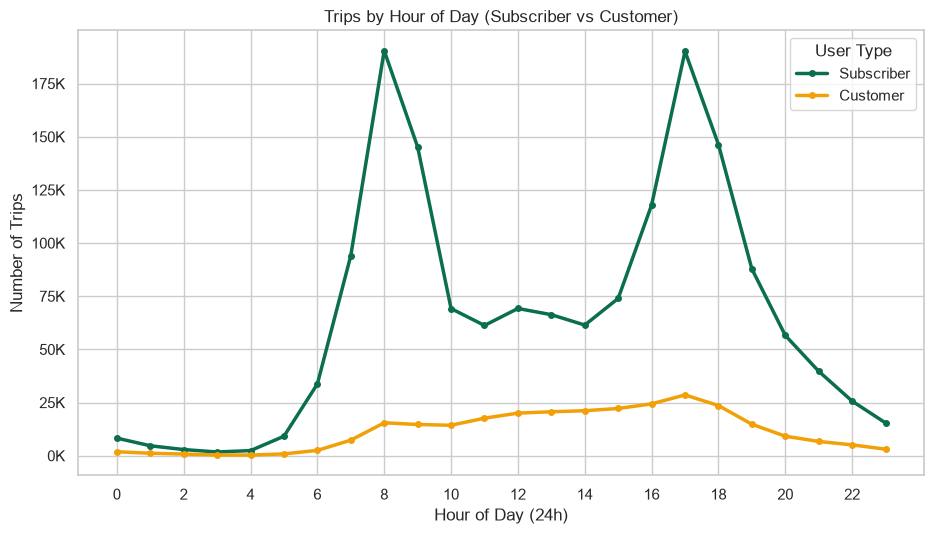

In [16]:
# Chart - 4 visualization code
hourly = analysis.groupby(['start_hour','user_type'], observed=True).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for ut, color in [('Subscriber', PALETTE['primary']), ('Customer', PALETTE['accent'])]:
    sub = hourly[hourly['user_type']==ut]
    ax.plot(sub['start_hour'], sub['count'], marker='o', ms=4, label=ut, color=color, lw=2.5)
ax.set_title('Trips by Hour of Day (Subscriber vs Customer)')
ax.set_xlabel('Hour of Day (24h)'); ax.set_ylabel('Number of Trips'); ax.set_xticks(range(0,24,2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
ax.legend(title='User Type'); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A line chart is ideal for showing a trend across an **ordered continuous axis (hour of day)**, and plotting Subscriber and Customer as two separate series makes the shape difference between the groups immediately comparable.

##### 2. What is/are the insight(s) found from the chart?

Subscribers show a **sharp bimodal commute pattern** — a tall peak around 8 AM and an even taller peak around 5 PM, with a trough mid-day. Customers show a **flatter, single-hump pattern** that builds through the late morning and peaks in the early-to-mid afternoon, with much lower amplitude. This confirms the earlier finding: Subscribers commute on a fixed schedule; Customers ride more spontaneously through the day.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is directly actionable for **fleet rebalancing** — bikes need to be pushed toward residential/outer stations before the 8 AM peak and toward downtown/business stations before the 5 PM peak. Staffing and rebalancing trucks can be scheduled around these two sharp windows rather than spread evenly through the day, reducing operating cost.

#### Chart - 5

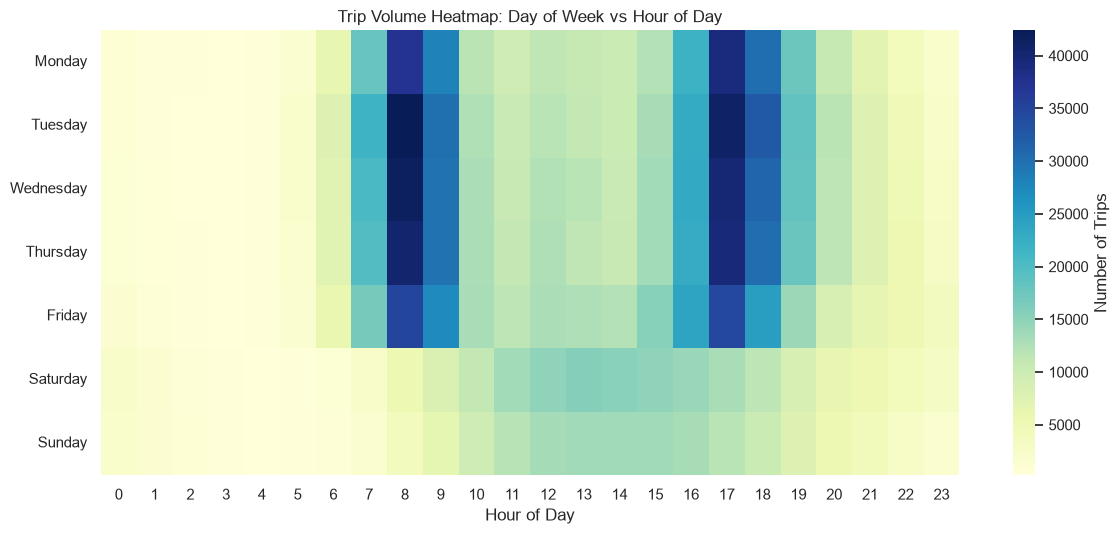

In [17]:
# Chart - 5 visualization code
pivot = analysis.pivot_table(index='start_day_of_week', columns='start_hour', values='duration_sec',
                              aggfunc='count').reindex(order_days)
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(pivot, cmap='YlGnBu', ax=ax, cbar_kws={'label':'Number of Trips'})
ax.set_title('Trip Volume Heatmap: Day of Week vs Hour of Day'); ax.set_xlabel('Hour of Day'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A heatmap efficiently packs **two categorical/ordinal axes and one intensity value** into a single readable grid — far more compact than 7 separate hourly line charts, and it makes the weekday-vs-weekend pattern shift visually obvious at a glance.

##### 2. What is/are the insight(s) found from the chart?

The two commute peaks (8 AM and 5 PM) are visible as **dark vertical bands only on Monday–Friday**; Saturday and Sunday instead show a **single broad warm band from roughly 10 AM to 4 PM**, with no sharp double peak. This is the clearest single visual confirmation of the whole "commute vs. leisure" story in the dataset.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this heatmap can act as a **rebalancing schedule template** — operations can literally read off, for each day and hour, when demand is highest and pre-position bikes accordingly, rather than relying on a single flat daily plan that would over-serve weekends and under-serve weekday peaks.

#### Chart - 6

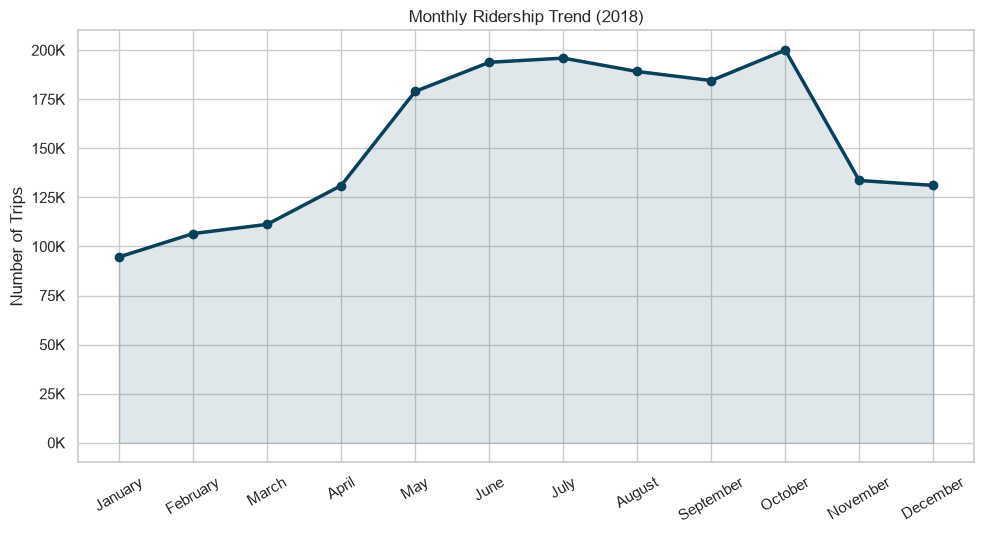

start_month_name
January       94658
February     106565
March        111253
April        131024
May          178980
June         193788
July         195944
August       189123
September    184505
October      200020
November     133594
December     131103
Name: count, dtype: int64

In [18]:
# Chart - 6 visualization code
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
month_counts = analysis['start_month_name'].value_counts().reindex(month_order)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(month_counts.index, month_counts.values, marker='o', color=PALETTE['secondary'], lw=2.5, ms=6)
ax.fill_between(range(len(month_counts)), month_counts.values, color=PALETTE['secondary'], alpha=0.12)
ax.set_title('Monthly Ridership Trend (2018)'); ax.set_ylabel('Number of Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
plt.xticks(rotation=30); plt.tight_layout(); plt.show()
month_counts

##### 1. Why did you pick the specific chart?

A line chart over the 12 ordered months is the standard way to reveal **seasonality/trend** in time-series-like data.

##### 2. What is/are the insight(s) found from the chart?

Ridership **climbs steadily from January (94.7K trips) to a peak in October (200.0K)**, roughly doubling, then drops off through November–December. This is a classic seasonal pattern driven by weather (more daylight, milder temperatures May–October) as well as the system's own service expansion during 2018.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive: fleet size, maintenance staffing, and marketing spend can be **seasonally weighted** — ramp up bike availability and maintenance capacity heading into spring, and use the winter lull for fleet servicing and station maintenance. Negative-growth risk: the **Nov–Dec drop-off** (partly seasonal, partly daylight-saving related) is a period where idle bikes/docks tie up capital — winter promotions (e.g., discounted day passes) could partially offset the seasonal dip.

#### Chart - 7

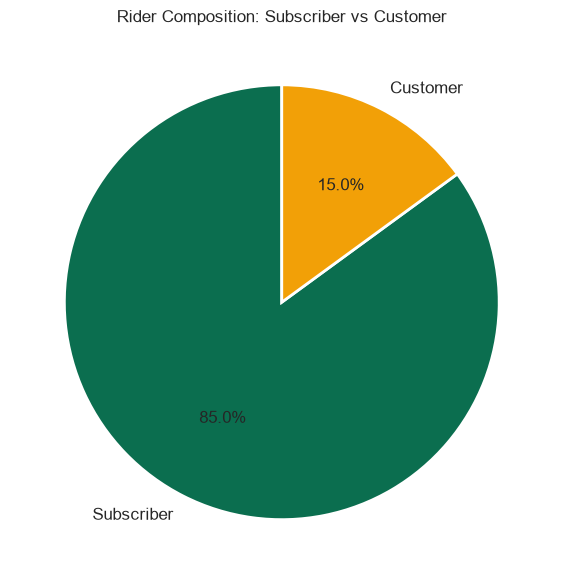

In [19]:
# Chart - 7 visualization code
ut_counts = analysis['user_type'].value_counts()
fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(ut_counts.values, labels=ut_counts.index, colors=[PALETTE['primary'], PALETTE['accent']],
       autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':12})
ax.set_title('Rider Composition: Subscriber vs Customer')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is appropriate here because there are only **two mutually-exclusive categories** summing to 100% of trips, and the business question is simply "what share of trips is each type" — a case where pie charts are actually well suited (few slices, part-of-whole framing).

##### 2. What is/are the insight(s) found from the chart?

**85.0% of all trips are made by Subscribers**, and only **15.0% by Customers**. The system's core, recurring user base is overwhelmingly annual-member commuters, not casual riders.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms the subscription/membership revenue line is the core of the business and should be protected and grown first (retention programs, employer partnerships). Growth angle: the **15% Customer share is a comparatively small acquisition funnel** — converting more one-off Customers into Subscribers (e.g., a "your Nth ride this month — upgrade and save" prompt) is a clear, data-backed growth lever.

#### Chart - 8

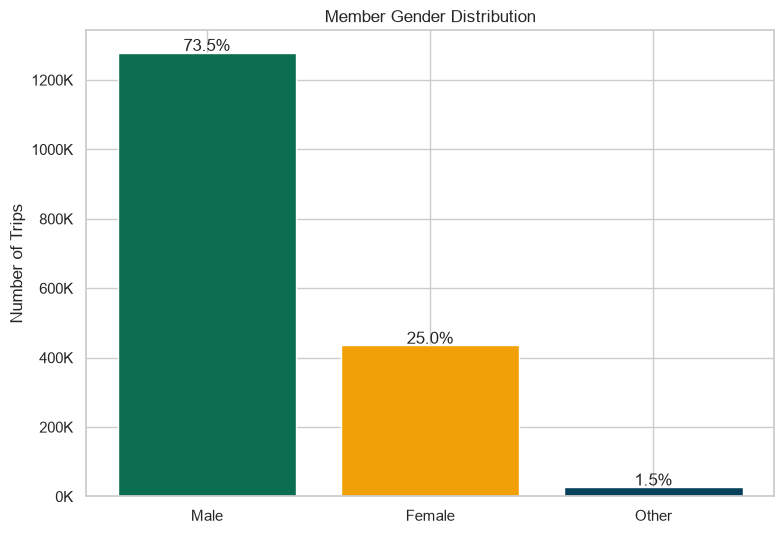

In [20]:
# Chart - 8 visualization code
gender_counts = analysis['member_gender'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(gender_counts.index, gender_counts.values, color=[PALETTE['primary'], PALETTE['accent'], PALETTE['secondary']])
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5000, f'{b.get_height()/gender_counts.sum()*100:.1f}%', ha='center')
ax.set_title('Member Gender Distribution'); ax.set_ylabel('Number of Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A bar chart clearly compares counts across the **3 discrete gender categories** reported in the data, with percentage labels added for precision since a pie chart with 3 uneven slices is harder to read accurately.

##### 2. What is/are the insight(s) found from the chart?

Among riders who reported gender, **73.5% identify as Male, 25.0% as Female, and 1.5% as Other** — a substantial gender gap in ridership (note: ~6% of all trips have no gender reported and are excluded from this specific chart).

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

This is a **growth opportunity, not a negative**: closing part of the gender gap (e.g., through safety-focused infrastructure messaging, well-lit route recommendations, or targeted campaigns) could meaningfully grow the Female rider segment, which currently represents a quarter of the base. Any campaign should be tested and measured, since the underlying causes of the gap (safety perception, trip purpose, neighborhood coverage) are not directly visible in this dataset.

#### Chart - 9

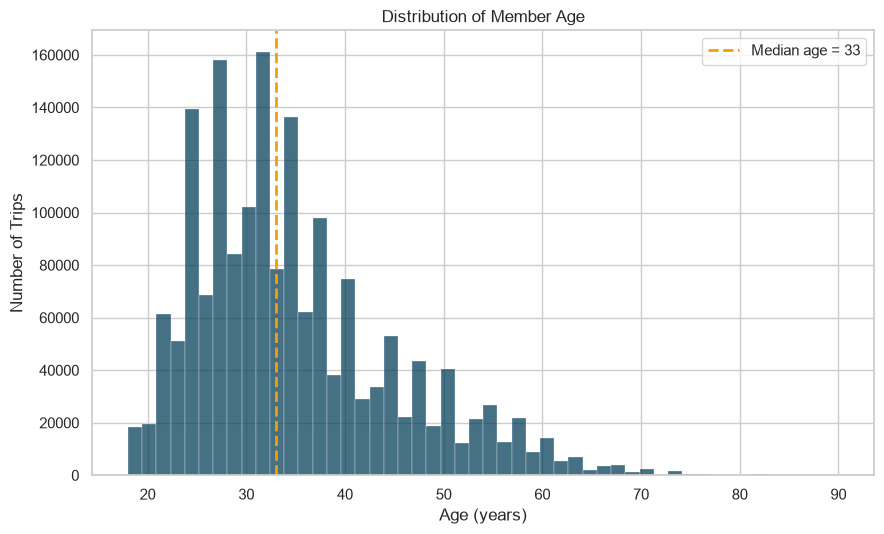

count    1.740163e+06
mean     3.487757e+01
std      1.021315e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      9.000000e+01
Name: age, dtype: float64

In [21]:
# Chart - 9 visualization code
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.histplot(analysis['age'].dropna(), bins=50, color=PALETTE['secondary'], ax=ax, edgecolor='white', linewidth=0.2)
ax.axvline(analysis['age'].median(), color=PALETTE['accent'], ls='--', lw=2, label=f"Median age = {analysis['age'].median():.0f}")
ax.set_title('Distribution of Member Age'); ax.set_xlabel('Age (years)'); ax.set_ylabel('Number of Trips')
ax.legend(); plt.tight_layout(); plt.show()
analysis['age'].describe()

##### 1. Why did you pick the specific chart?

A histogram again best reveals the **shape** of this continuous variable's distribution (skew, spread, typical range) rather than just a single summary number.

##### 2. What is/are the insight(s) found from the chart?

Rider age is **right-skewed and concentrated in working-age adults**: median age 33, mean ~34.9, with the bulk of riders between roughly 25 and 40. This lines up cleanly with the commute-dominated usage pattern seen earlier — the system's core users are young/early-career professionals.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive: marketing creative, partnership targeting (e.g., tech-company commuter benefit programs), and even station siting decisions can be tuned toward the **25–40 professional demographic** that already dominates ridership. The narrower tail above ~55 suggests an under-served older-adult segment that could be a longer-term expansion target with different messaging (health/leisure framing rather than commute framing).

#### Chart - 10

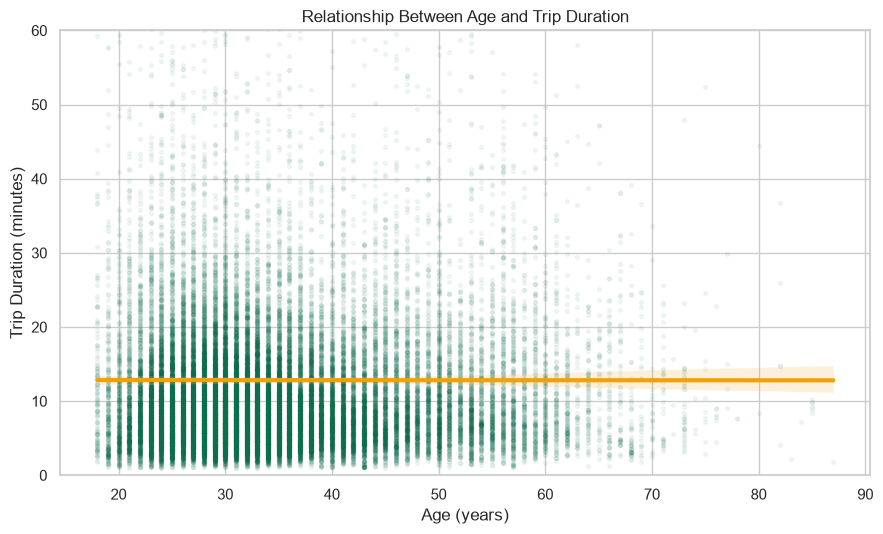

Correlation (age vs duration): -0.0014


In [22]:
# Chart - 10 visualization code
sample = analysis.dropna(subset=['age']).sample(n=40000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.regplot(data=sample, x='age', y='duration_min', ax=ax,
            scatter_kws={'alpha':0.05, 's':8, 'color':PALETTE['primary']}, line_kws={'color':PALETTE['accent'], 'lw':3})
ax.set_ylim(0, 60)
ax.set_title('Relationship Between Age and Trip Duration'); ax.set_xlabel('Age (years)'); ax.set_ylabel('Trip Duration (minutes)')
plt.tight_layout(); plt.show()
print("Correlation (age vs duration):", analysis[['age','duration_min']].dropna().corr().iloc[0,1].round(4))

##### 1. Why did you pick the specific chart?

A scatter plot with a fitted regression line is the standard way to inspect a **relationship between two continuous variables**; low alpha transparency is used to handle severe overplotting from 40,000 points.

##### 2. What is/are the insight(s) found from the chart?

The regression line is essentially **flat** and the correlation coefficient is ≈ **-0.001** — there is **no meaningful linear relationship between a rider's age and how long their trip is**. Trip duration is driven much more strongly by *user type* (Chart 2) and *time of day* than by age.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

This is a useful **negative result**: it tells the business *not* to build age-tiered pricing or age-based duration assumptions, since age carries no predictive signal for ride length. Effort is better spent on the user-type and time-of-day segmentation that the earlier charts *do* show to be meaningful.

#### Chart - 11

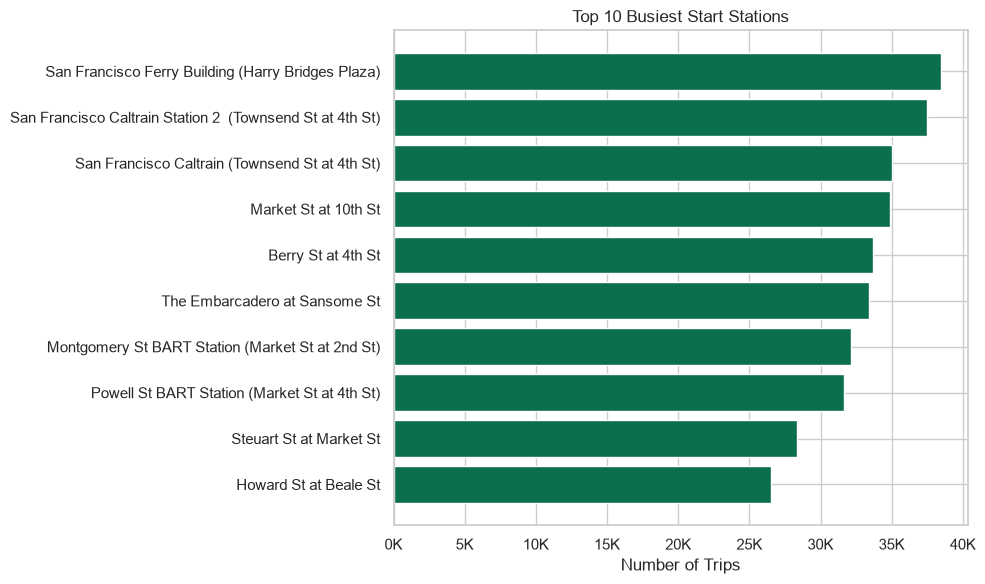

start_station_name
San Francisco Ferry Building (Harry Bridges Plaza)           38451
San Francisco Caltrain Station 2  (Townsend St at 4th St)    37510
San Francisco Caltrain (Townsend St at 4th St)               35043
Market St at 10th St                                         34899
Berry St at 4th St                                           33674
The Embarcadero at Sansome St                                33380
Montgomery St BART Station (Market St at 2nd St)             32121
Powell St BART Station (Market St at 4th St)                 31651
Steuart St at Market St                                      28334
Howard St at Beale St                                        26533
Name: count, dtype: int64

In [23]:
# Chart - 11 visualization code
top_stations = analysis['start_station_name'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_stations.index[::-1], top_stations.values[::-1], color=PALETTE['primary'])
ax.set_title('Top 10 Busiest Start Stations'); ax.set_xlabel('Number of Trips')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
plt.tight_layout(); plt.show()
top_stations

##### 1. Why did you pick the specific chart?

A horizontal bar chart handles the **long station-name labels** cleanly and ranks categories by count — the right choice whenever the goal is "show me the top N" of a categorical variable.

##### 2. What is/are the insight(s) found from the chart?

The busiest stations are dominated by **major transit hubs**: San Francisco Ferry Building, Caltrain Station (both entries — the station was relocated mid-year, splitting its trip count across two names), and Market St corridor stations. These 10 stations alone account for well over 300,000 trips combined — a small fraction of the network's 331 stations handling a disproportionate share of demand.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is a direct **rebalancing and maintenance priority list** — these stations need the most frequent bike replenishment, dock repair, and monitoring. It also flags a data-quality note for the business: the Caltrain station's two names should be **merged into one canonical station ID** in the source system so future counts aren't artificially split.

#### Chart - 12

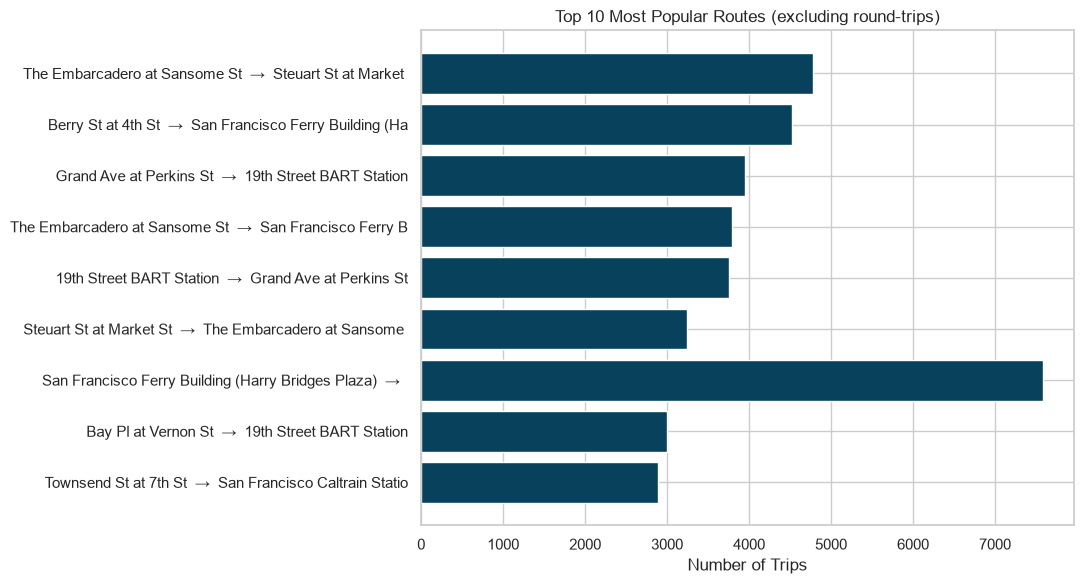

route
San Francisco Ferry Building (Harry Bridges Plaza)  →  The Embarcadero at Sansome St    7584
The Embarcadero at Sansome St  →  Steuart St at Market St                               4776
Berry St at 4th St  →  San Francisco Ferry Building (Harry Bridges Plaza)               4519
Grand Ave at Perkins St  →  19th Street BART Station                                    3952
The Embarcadero at Sansome St  →  San Francisco Ferry Building (Harry Bridges Plaza)    3793
19th Street BART Station  →  Grand Ave at Perkins St                                    3758
Steuart St at Market St  →  The Embarcadero at Sansome St                               3246
San Francisco Ferry Building (Harry Bridges Plaza)  →  Berry St at 4th St               3227
Bay Pl at Vernon St  →  19th Street BART Station                                        2993
Townsend St at 7th St  →  San Francisco Caltrain Station 2  (Townsend St at 4th St)     2884
Name: count, dtype: int64

In [24]:
# Chart - 12 visualization code
top_routes = analysis[~analysis['same_station']]['route'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh([r[:55] for r in top_routes.index[::-1]], top_routes.values[::-1], color=PALETTE['secondary'])
ax.set_title('Top 10 Most Popular Routes (excluding round-trips)'); ax.set_xlabel('Number of Trips')
plt.tight_layout(); plt.show()
top_routes

##### 1. Why did you pick the specific chart?

Same reasoning as Chart 11 — horizontal bars for a ranked categorical (here, a compound start→end route) variable with long text labels.

##### 2. What is/are the insight(s) found from the chart?

The top route — **Ferry Building → The Embarcadero at Sansome St** — alone accounts for over 7,500 trips in the year, and the top-10 list is dominated by **short waterfront/downtown hops** between transit hubs and nearby office clusters, reinforcing the "quick commute-leg" usage pattern.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Positive: these fixed high-traffic corridors are strong candidates for **dedicated bike lane advocacy or infrastructure investment proposals** to city partners, since the data quantifies exact demand along specific streets, and for pre-emptive rebalancing (moving bikes along the reverse direction of the commute flow before the opposing peak).

#### Chart - 13

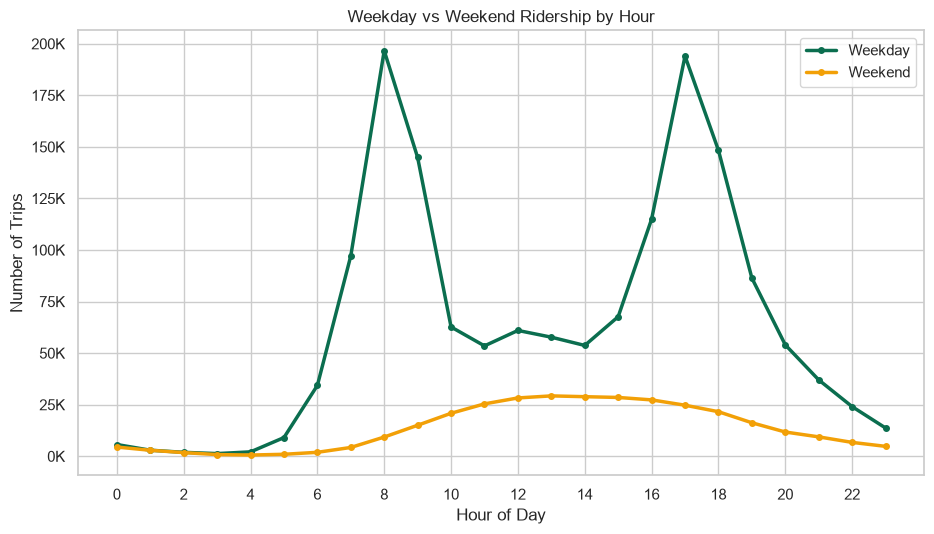

In [25]:
# Chart - 13 visualization code
hr_wk = analysis.groupby(['start_hour','is_weekend'], observed=True).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for wk, label, color in [(False,'Weekday',PALETTE['primary']), (True,'Weekend',PALETTE['accent'])]:
    sub = hr_wk[hr_wk['is_weekend']==wk]
    ax.plot(sub['start_hour'], sub['count'], marker='o', ms=4, label=label, color=color, lw=2.5)
ax.set_title('Weekday vs Weekend Ridership by Hour'); ax.set_xlabel('Hour of Day'); ax.set_ylabel('Number of Trips')
ax.set_xticks(range(0,24,2)); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))
ax.legend(); plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

This mirrors Chart 4's design (line chart, two series over hour-of-day) but splits by weekday/weekend instead of user type — a deliberate double-check that the commute pattern is really a *day-type* effect and not purely a *user-type* artifact.

##### 2. What is/are the insight(s) found from the chart?

The weekday line reproduces the sharp AM/PM double-peak; the weekend line is **lower in absolute volume and single-peaked**, cresting gently in the early afternoon. This chart, combined with Chart 5's heatmap, confirms the pattern is robust and not driven by any single rider segment alone.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

Reinforces the same rebalancing and staffing recommendations as Charts 4–5: **weekday operations need a two-peak strategy; weekend operations need a single mid-day push** — and weekend capacity can safely be lower overall, freeing staff/trucks for weekday peak coverage.

#### Chart - 14 - Correlation Heatmap

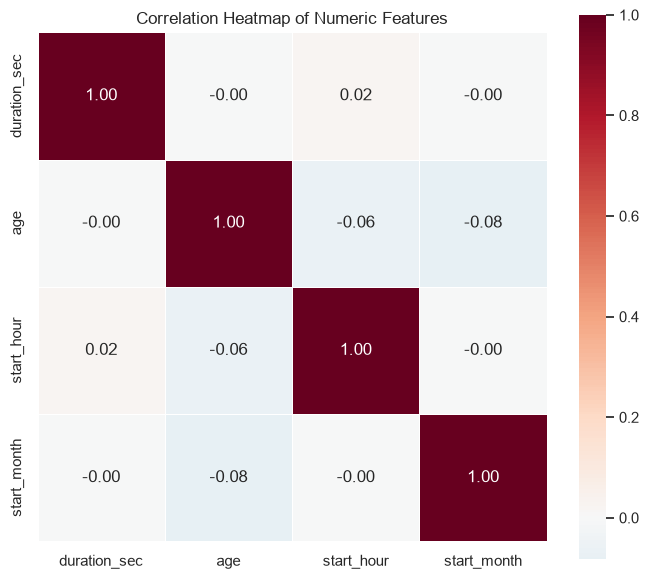

In [26]:
# Correlation Heatmap visualization code
num_cols = ['duration_sec','age','start_hour','start_month']
corr = analysis[num_cols].dropna().corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap of Numeric Features')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard, compact way to scan **every pair of numeric variables at once** for linear relationships before deciding which pairs deserve a deeper scatter-plot look.

##### 2. What is/are the insight(s) found from the chart?

All pairwise correlations among `duration_sec`, `age`, `start_hour`, and `start_month` are **very close to zero** (the strongest is still well under 0.05 in magnitude). This confirms, quantitatively, what Chart 10 showed for age: **none of these numeric variables linearly predict trip duration** — duration is instead driven by the categorical `user_type` split (Chart 2), not by when-in-the-day/year the trip happens or the rider's age.

##### 3. Will the gained insights help creating a positive business impact? | Are there any insights that lead to negative growth? Justify with specific reason.

This tells the analytics/data-science team that any future predictive model for trip duration should **prioritize categorical/behavioral features (user type, station pair, weekday/weekend) over these numeric ones**, saving modeling effort from chasing weak linear signals that don't exist in this data.

#### Chart - 15 - Pair Plot

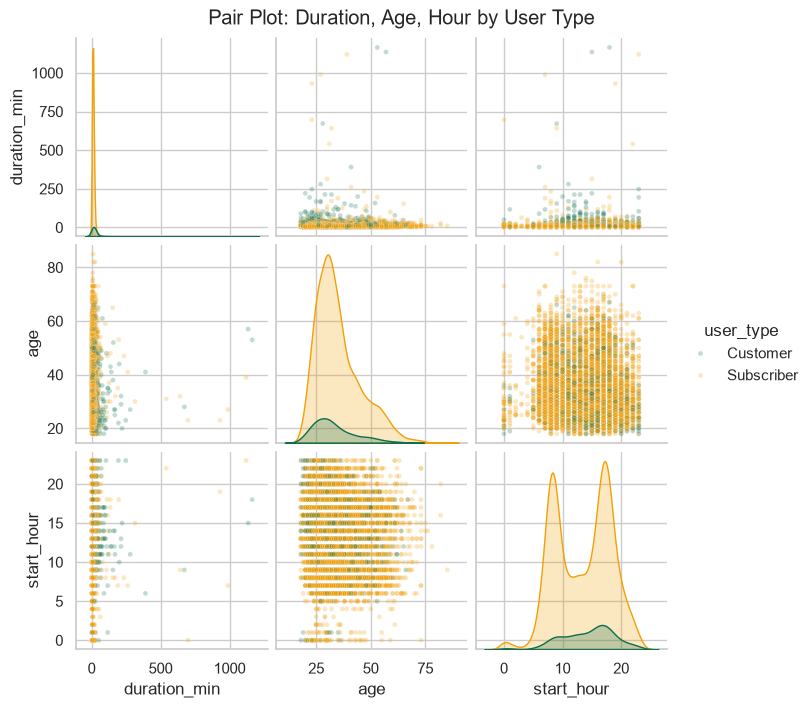

In [27]:
# Pair Plot visualization code
pp_sample = analysis.dropna(subset=['age']).sample(n=8000, random_state=42)[['duration_min','age','start_hour','user_type']]
g = sns.pairplot(pp_sample, hue='user_type', palette=[PALETTE['primary'], PALETTE['accent']],
                  plot_kws={'alpha':0.25, 's':12}, diag_kind='kde', height=2.3)
g.fig.suptitle('Pair Plot: Duration, Age, Hour by User Type', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives a **single, comprehensive grid of every pairwise relationship plus each variable's own distribution**, split by `user_type` — an efficient final sanity check that ties together everything found individually in Charts 2, 4, 9, and 10.

##### 2. What is/are the insight(s) found from the chart?

The diagonal KDEs re-confirm the **Customer duration distribution is shifted right (longer) and more spread out** than Subscriber's, while the age distributions of the two groups largely overlap. Off-diagonal panels show **no visible linear structure** between duration, age, and hour — flat, cloud-like scatter in every panel — reconfirming that `user_type` is the dominant explanatory variable in this dataset, not the numeric features.

##### 2. What is/are the insight(s) found from the chart? (continued)

No new relationship emerges beyond what Charts 2, 4, 9 and 10 already established — which is itself a useful, honest conclusion: **user type, not age or time-of-day, is the single strongest driver of trip duration** in this dataset.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ? Explain Briefly.

Based on the evidence gathered across all 15 charts, here are concrete, prioritized recommendations for Bay Wheels' operations and marketing teams:

1. **Rebalance bikes on a two-peak weekday schedule, not a flat daily plan.** Charts 4, 5 and 13 all show a sharp 8 AM / 5 PM double-peak on weekdays and a single broad mid-day peak on weekends. Concentrate rebalancing trucks and staff around these two weekday windows and scale weekend operations down to a single mid-day push.
2. **Prioritize the top 10–20 stations and routes for maintenance and dock capacity** (Chart 11, 12) — Ferry Building, Caltrain, and Market St corridor stations absorb a disproportionate share of trips and should never run out of docks/bikes. Also fix the Caltrain-station name split in the source system so trip counts aren't fragmented across two IDs.
3. **Protect and grow the Subscriber base first** (Chart 7) — it drives 85% of trips. Retention perks and employer commuter-benefit partnerships targeting the 25–40 professional demographic (Chart 9) will have the largest revenue impact per dollar spent.
4. **Use the Subscriber/Customer duration gap (Chart 2) to justify tiered pricing** — a "free first ~15 minutes" allowance covers the large majority of Subscriber trips at near-zero marginal cost while still monetizing Customers' longer average rides through overage fees.
5. **Treat the 15% Customer segment and the weekend gap (Charts 3, 7) as the primary growth funnel** — run weekend-specific promotions and a "ride N times, upgrade to a membership and save" conversion prompt for repeat Customers.
6. **Address the gender gap (Chart 8)** with targeted, measurable campaigns (safety-focused route guidance, women-focused ride communities) to grow the current 25% Female ridership share.
7. **Don't invest in age- or time-of-day-based duration modeling** (Charts 10, 14, 15) — these show essentially zero correlation with trip length. Any future predictive or pricing model should be built around `user_type` and station/route features instead, which is where the real signal lives.
8. **Operationally flag any trip exceeding ~4 hours** for staff follow-up, since the 24-hour platform cap (Chart 1) is almost certainly capturing lost/stranded bikes rather than genuine long rides, and each one removes a bike from the active fleet for the rest of the day.

# **Conclusion**

This EDA analyzed **1,863,721 Ford GoBike trips from 2018**, working from raw monthly CSVs through cleaning, feature engineering, and 15 purposefully-chosen visualizations to a data-driven answer for the core business question and several supporting ones.

**Headline answer (trip duration):** the mean trip lasts **≈14.2 minutes** and the median **≈9.25 minutes**, with the gap between them explained by a right-skewed distribution and a 24-hour platform-enforced cap. Trips range from ~1 minute to 24 hours.

**Supporting findings:** the system is a **commute-first platform** — 85% Subscriber trips, sharp weekday AM/PM peaks, and a median rider age of 33 — with Customers representing a smaller but distinctly different (longer, more weekend-skewed, more leisure-oriented) segment. A handful of downtown/transit-adjacent stations and routes absorb outsized demand, while age, hour, and month show essentially no linear relationship with trip duration — user type and time-of-week are the variables that actually matter for planning.

Together, these findings translate into concrete recommendations across rebalancing scheduling, station/maintenance prioritization, tiered pricing, and targeted growth campaigns for the Customer and Female-rider segments, giving Bay Wheels' operations and marketing teams an evidence base for their next planning cycle.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***